# OpenBat vs. Echo Meter Touch 2 Pro — Comparative Analysis

A simultaneous field session, same GPS spot, recorded by two systems at once:
- **OpenBat** (Griff USB mic, iPad, 384 kHz)
- **Wildlife Acoustics Echo Meter Touch 2 Pro** (iPhone, 256 kHz) — the more established, commercial reference point

Two questions this notebook answers:

**A. How often do the two classifiers agree on species, and how confident is OpenBat when they do/don't?**
OpenBat's species IDs here come from `bat_classifier_log.csv` (the app's own per-pulse classification log), matched to each recorded WAV by timestamp and backfilled into that file's GUANO chunk — this session was recorded before the app wrote species IDs live, so the comparison below is GUANO-to-GUANO either way. EchoTouch doesn't expose its own confidence score in its metadata, so confidence detail is only available for OpenBat; the comparison there is about how OpenBat's own certainty relates to whether it agreed with EchoTouch's call.

**B. How does the hardware/software stack compare on detection quality?**
Not species ID — just: does it trigger on the same events, how strong is the recorded signal, how does timing line up. This doesn't require either device's classifier to be "right," just the raw audio.

Neither device is ground truth. Read every "agreement"/"recall" number as *relative agreement between two non-reference systems*, not a verdict on which one is correct.


In [1]:
from pathlib import Path
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import soundfile as sf
from datetime import datetime, timezone, timedelta
import csv as csv_module

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

DATA_DIR = Path('/Users/niallbell/Downloads/Test Data')
OPENBAT_DIR = DATA_DIR / 'OpenBat'
ECHOTOUCH_DIR = DATA_DIR / 'EchoTouch'
PULSE_LOG_CSV = Path('/Users/niallbell/Downloads/bat_classifier_log 4.csv')  # OpenBat's per-pulse classifier log

assert OPENBAT_DIR.exists(), f"Missing {OPENBAT_DIR}"
assert ECHOTOUCH_DIR.exists(), f"Missing {ECHOTOUCH_DIR}"

COLORS = {'OpenBat': 'tab:blue', 'EchoTouch': 'tab:orange'}

def violin(ax, data_list, labels, colors):
    """Two-group violin plot with explicit per-violin colors (avoids seaborn's hue
    inference, which misfires for a plain list of arrays)."""
    parts = ax.violinplot([d for d in data_list], showmeans=True)
    for body, color in zip(parts['bodies'], colors):
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(0.8)
    for key in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
        parts[key].set_color('black')
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)


## Setup: loading metadata

Both devices embed a `guan` RIFF chunk (the GUANO bat-acoustics metadata standard) with `Key: Value` text lines — timestamp, duration, sample rate, GPS and, for both devices now, a species Auto ID.


In [2]:
def read_riff_chunks(path):
    with open(path, 'rb') as f:
        data = f.read()
    assert data[:4] == b'RIFF', f"Not a RIFF file: {path}"
    pos = 12
    chunks = {}
    while pos < len(data) - 8:
        cid = data[pos:pos+4]
        size = struct.unpack('<I', data[pos+4:pos+8])[0]
        chunks[cid] = data[pos+8:pos+8+size]
        pos += 8 + size + (size % 2)
    return chunks

def parse_guano(raw_bytes):
    fields = {}
    for line in raw_bytes.decode('utf-8', errors='replace').splitlines():
        if ':' not in line:
            continue
        key, _, value = line.partition(':')
        fields[key.strip()] = value.strip()
    return fields

def parse_timestamp(ts):
    """Handle both 'YYYY-MM-DDTHH:MM:SSZ' (OpenBat) and 'YYYY-MM-DD HH:MM:SS-0700' (EchoTouch)."""
    ts = ts.strip()
    if ts.endswith('Z'):
        dt = datetime.strptime(ts, '%Y-%m-%dT%H:%M:%SZ').replace(tzinfo=timezone.utc)
    else:
        dt = datetime.strptime(ts, '%Y-%m-%d %H:%M:%S%z')
    return dt.astimezone(timezone.utc)

# WA 6-letter code -> NABat 4-letter code, so OpenBat and EchoTouch calls compare on
# the same scale (same species, different naming convention between the two systems).
SPECIES_CROSSWALK = {
    'ANTPAL': 'ANPA', 'CORTOW': 'COTO', 'EPTFUS': 'EPFU', 'EUDMAC': 'EUMA',
    'EUMPER': 'EUPE', 'IDIPHY': 'IDPH', 'LASBLO': 'LABL', 'LASBOR': 'LABO',
    'LASCIN': 'LACI', 'LASINT': 'LAIN', 'LASNOC': 'LANO', 'LASSEM': 'LASE',
    'MYOAUS': 'MYAU', 'MYOCAL': 'MYCA', 'MYOCIL': 'MYCI', 'MYOEVO': 'MYEV',
    'MYOGRI': 'MYGR', 'MYOLEI': 'MYLE', 'MYOLUC': 'MYLU', 'MYOSEP': 'MYSE',
    'MYOSOD': 'MYSO', 'MYOTHY': 'MYTH', 'MYOVEL': 'MYVE', 'MYOVOL': 'MYVO',
    'MYOYUM': 'MYYU', 'NYCHUM': 'NYHU', 'NYCMAC': 'NYMA', 'PARHES': 'PAHE',
    'PERSUB': 'PESU', 'TADBRA': 'TABR', 'NOISE': 'NOISE',
}
NO_ID_TOKENS = {'No ID', 'NoID', ''}

def normalize_species(code):
    if code in NO_ID_TOKENS or pd.isna(code):
        return 'No ID'
    return SPECIES_CROSSWALK.get(code, code)

def load_openbat_row(path):
    g = parse_guano(read_riff_chunks(path).get(b'guan', b''))
    return {
        'source': 'OpenBat',
        'path': path,
        'filename': path.name,
        'timestamp_utc': parse_timestamp(g['Timestamp']),
        'duration_s': float(g.get('Length', np.nan)),
        'samplerate': int(g.get('Samplerate', 0)),
        'species_auto_id': normalize_species(g.get('Species Auto ID')),
        'species_confidence': float(g['OpenBat|Species Confidence']) if 'OpenBat|Species Confidence' in g else np.nan,
        'species_pulse_count': int(g['OpenBat|Species Pulse Count']) if 'OpenBat|Species Pulse Count' in g else 0,
        'lat': np.nan, 'lon': np.nan,
    }

def load_echotouch_row(path):
    g = parse_guano(read_riff_chunks(path).get(b'guan', b''))
    lat = lon = np.nan
    pos = g.get('Loc Position')
    if pos and len(pos.split()) == 2:
        lat, lon = map(float, pos.split())
    return {
        'source': 'EchoTouch',
        'path': path,
        'filename': path.name,
        'timestamp_utc': parse_timestamp(g['Timestamp']),
        'duration_s': float(g.get('Length', np.nan)),
        'samplerate': int(g.get('Samplerate', 0)),
        'species_auto_id': normalize_species(g.get('Species Auto ID')),
        'species_confidence': np.nan,  # not exposed by Echo Meter Touch's metadata
        'species_pulse_count': 0,
        'lat': lat, 'lon': lon,
    }

ob_files = sorted(OPENBAT_DIR.glob('pass-*.wav'))
et_files = sorted(ECHOTOUCH_DIR.glob('*.wav'))

ob_df = pd.DataFrame([load_openbat_row(p) for p in ob_files])
et_df = pd.DataFrame([load_echotouch_row(p) for p in et_files])

df = pd.concat([ob_df, et_df], ignore_index=True).sort_values('timestamp_utc').reset_index(drop=True)
df['end_utc'] = df['timestamp_utc'] + pd.to_timedelta(df['duration_s'], unit='s')

print(f"OpenBat: {len(ob_df)} passes, {len(ob_df) - (ob_df.species_auto_id == 'No ID').sum()} with a species call")
print(f"EchoTouch: {len(et_df)} passes, {len(et_df) - (et_df.species_auto_id == 'No ID').sum()} with a species call")


OpenBat: 158 passes, 145 with a species call
EchoTouch: 72 passes, 37 with a species call


In [3]:
def analyze_audio(path):
    audio, sr = sf.read(path, dtype='float32')
    if audio.ndim > 1:
        audio = audio[:, 0]
    if len(audio) < 256:
        return dict(snr_db=np.nan, peak_freq_hz=np.nan, bandwidth_hz=np.nan)

    from scipy.signal import stft
    f, t, Z = stft(audio, fs=sr, nperseg=512, noverlap=256, window='hann')
    power_db = 20 * np.log10(np.abs(Z) + 1e-12)

    band_mask = f >= 10_000  # ignore DC / handling noise below plausible bat range
    power_band = power_db[band_mask]
    f_band = f[band_mask]

    frame_energy = power_band.max(axis=0)
    peak_dbfs = float(frame_energy.max())
    n_quiet = max(1, int(0.2 * len(frame_energy)))
    noise_floor_dbfs = float(np.sort(frame_energy)[:n_quiet].mean())

    peak_frame_idx = int(np.argmax(frame_energy))
    peak_freq_hz = float(f_band[np.argmax(power_band[:, peak_frame_idx])])
    frame_col = power_band[:, peak_frame_idx]
    above = f_band[frame_col >= (frame_col.max() - 10)]
    bandwidth_hz = float(above.max() - above.min()) if len(above) else np.nan

    return dict(snr_db=peak_dbfs - noise_floor_dbfs, peak_freq_hz=peak_freq_hz, bandwidth_hz=bandwidth_hz)

df = pd.concat([df, df['path'].apply(analyze_audio).apply(pd.Series)], axis=1)
print("Signal metrics computed for all", len(df), "passes.")


Signal metrics computed for all 230 passes.


## Setup: matching detections between devices

An OpenBat pass and an EchoTouch pass are treated as "the same bat event" if their time windows overlap once padded by a tolerance (two independent clocks are never perfectly synced, and neither trigger fires at exactly the same instant on the same call).


In [4]:
TOLERANCE_S = 2.0  # padding applied to each pass's [start, end] window before overlap test
tol = pd.Timedelta(seconds=TOLERANCE_S)

ob = df[df.source == 'OpenBat'].copy().sort_values('timestamp_utc').reset_index(drop=True)
et = df[df.source == 'EchoTouch'].copy().sort_values('timestamp_utc').reset_index(drop=True)

def match_events(a, b, tol):
    b_starts, b_ends = (b['timestamp_utc'] - tol).tolist(), (b['end_utc'] + tol).tolist()
    used_b = np.zeros(len(b), dtype=bool)
    matches = []
    for i, row in a.iterrows():
        a_start, a_end = row['timestamp_utc'] - tol, row['end_utc'] + tol
        candidates = [k for k in range(len(b)) if not used_b[k] and b_starts[k] <= a_end and b_ends[k] >= a_start]
        if not candidates:
            continue
        deltas = [abs((b.iloc[k]['timestamp_utc'] - row['timestamp_utc']).total_seconds()) for k in candidates]
        best = candidates[int(np.argmin(deltas))]
        used_b[best] = True
        matches.append((i, best))
    return matches

matches = match_events(ob, et, tol)
matched_ob_idx, matched_et_idx = {m[0] for m in matches}, {m[1] for m in matches}
ob_only, et_only = ob[~ob.index.isin(matched_ob_idx)], et[~et.index.isin(matched_et_idx)]

match_df = pd.DataFrame([{
    'ob_filename': ob.iloc[i]['filename'], 'et_filename': et.iloc[j]['filename'],
    'offset_s': (et.iloc[j]['timestamp_utc'] - ob.iloc[i]['timestamp_utc']).total_seconds(),
    'ob_species': ob.iloc[i]['species_auto_id'], 'et_species': et.iloc[j]['species_auto_id'],
    'ob_confidence': ob.iloc[i]['species_confidence'],
} for i, j in matches])

print(f"{len(matches)} matched events, {len(ob_only)} OpenBat-only, {len(et_only)} EchoTouch-only (±{TOLERANCE_S}s tolerance)")


62 matched events, 96 OpenBat-only, 10 EchoTouch-only (±2.0s tolerance)


---
# Part A — Species ID agreement

Restricted to the **matched events** — passes both devices actually triggered on — so any disagreement reflects the classifiers, not one device simply missing the call.


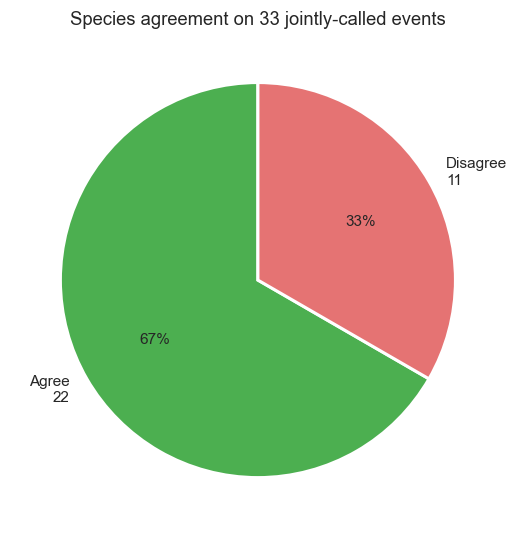

In [5]:
both_called = match_df[(match_df.ob_species != 'No ID') & (match_df.et_species != 'No ID')]
agree = both_called[both_called.ob_species == both_called.et_species]
agreement_rate = len(agree) / len(both_called) if len(both_called) else float('nan')

fig, ax = plt.subplots(figsize=(5, 5))
sizes = [len(agree), len(both_called) - len(agree)]
labels = [f'Agree\n{len(agree)}', f'Disagree\n{len(both_called) - len(agree)}']
ax.pie(sizes, labels=labels, colors=['#4CAF50', '#E57373'], autopct='%1.0f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title(f'Species agreement on {len(both_called)} jointly-called events')
plt.tight_layout()
plt.show()


**How to read this:** of the events where *both* devices were confident enough to name a species, this is the share where they named the *same* one. Treat it as a rough ceiling on how much you can trust either device's species call in isolation — if two independent systems only agree two-thirds of the time, a single call from either one (OpenBat or EchoTouch) on a new session should be treated as a hypothesis, not a fact, especially for genus-mate species (e.g. different *Myotis*) that sound similar and are hardest to tell apart acoustically.


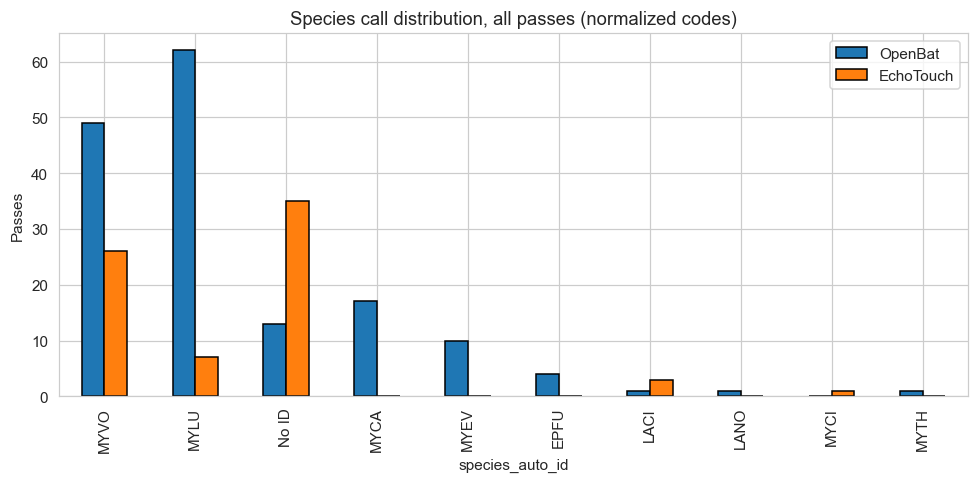

In [6]:
species_wide = pd.DataFrame({
    'OpenBat': ob['species_auto_id'].value_counts(),
    'EchoTouch': et['species_auto_id'].value_counts(),
}).fillna(0).astype(int)
species_wide = species_wide.loc[species_wide.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 4.5))
species_wide.plot(kind='bar', ax=ax, color=[COLORS['OpenBat'], COLORS['EchoTouch']], edgecolor='black')
ax.set_ylabel('Passes')
ax.set_title('Species call distribution, all passes (normalized codes)')
plt.tight_layout()
plt.show()


**How to read this:** this is each device's overall species mix for the whole session, independent of whether the other device agreed on any specific pass — it answers "what did each system think was flying around," not "did they agree." A big gap in `No ID` counts usually means one classifier's confidence threshold is stricter than the other's, not that one detector heard more bats.


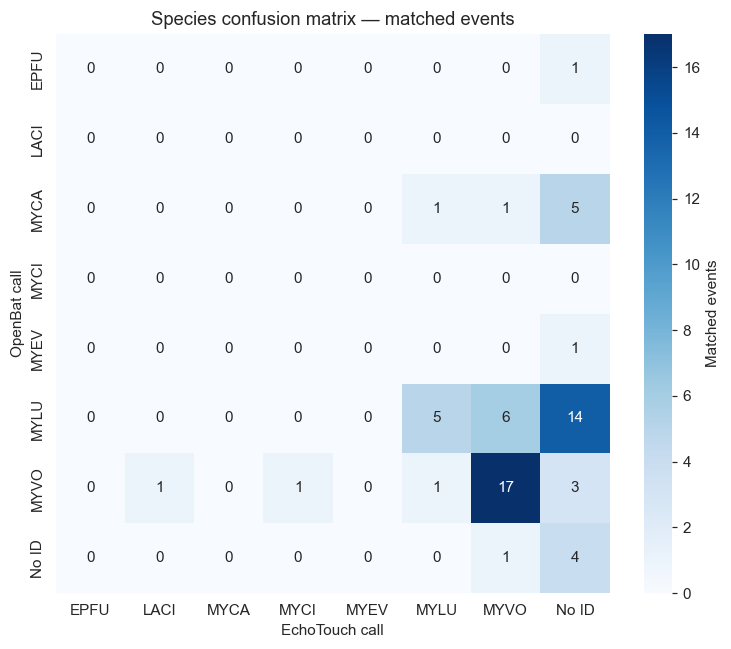

In [7]:
species_order = sorted(set(match_df.ob_species) | set(match_df.et_species))
confusion = pd.crosstab(match_df.ob_species, match_df.et_species).reindex(
    index=species_order, columns=species_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Matched events'}, ax=ax)
ax.set_xlabel('EchoTouch call')
ax.set_ylabel('OpenBat call')
ax.set_title('Species confusion matrix — matched events')
plt.tight_layout()
plt.show()


**How to read this:** the diagonal (top-left to bottom-right) is where the two devices named the same species — the darker and more concentrated the diagonal, the better the agreement. Off-diagonal cells are specific confusions: a strong off-diagonal cell means the two systems consistently disagree on that *pair* of calls (e.g. one says species X where the other says species Y), which is worth a manual spectrogram check on a couple of those files — it'll usually reveal whether it's a genuinely ambiguous call or a systematic bias in one classifier (e.g. a prior that's pulling too hard toward one common local species). A `No ID` row/column means one device didn't clear its own confidence threshold on that pass even though the other one did.


## OpenBat classifier confidence

EchoTouch doesn't expose a confidence score in its files, so this half is OpenBat-only — but it's still useful: it shows how much to trust an OpenBat call on its own, and whether low confidence is a leading indicator of disagreement with EchoTouch.

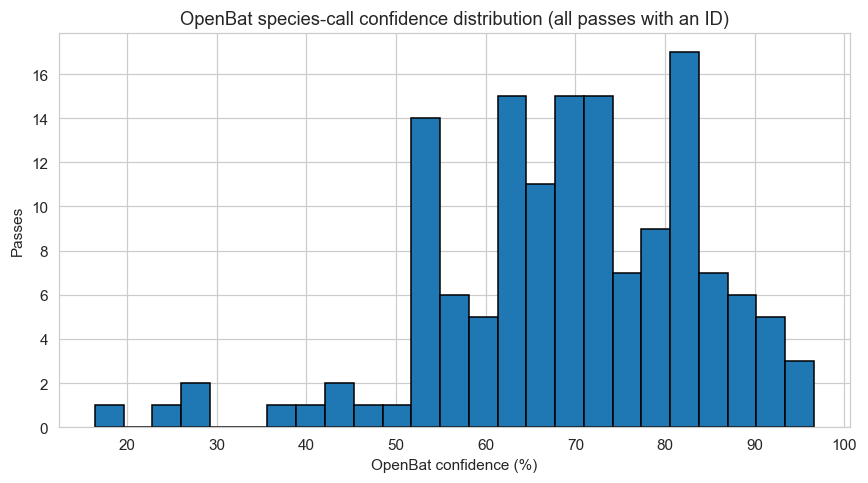

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ob.loc[ob.species_auto_id != 'No ID', 'species_confidence'] * 100, bins=25,
        color='tab:blue', edgecolor='black')
ax.set_xlabel('OpenBat confidence (%)')
ax.set_ylabel('Passes')
ax.set_title('OpenBat species-call confidence distribution (all passes with an ID)')
plt.tight_layout()
plt.show()


**How to read this:** a distribution stacked toward the low end means most OpenBat calls are only mildly more likely than the alternatives it considered — worth being cautious about treating any single low-confidence call as reliable. A distribution stacked toward the high end means the model is usually decisive one way or the other, which is generally the healthier shape for a field classifier (uncertain calls should look uncertain, not confidently wrong).


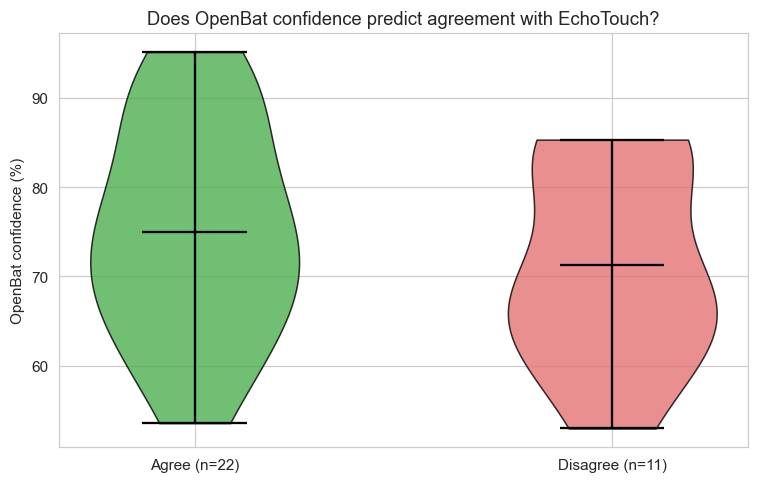

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
groups = [
    both_called.loc[both_called.ob_species == both_called.et_species, 'ob_confidence'].dropna() * 100,
    both_called.loc[both_called.ob_species != both_called.et_species, 'ob_confidence'].dropna() * 100,
]
violin(ax, groups, [f'Agree (n={len(groups[0])})', f'Disagree (n={len(groups[1])})'], ['#4CAF50', '#E57373'])
ax.set_ylabel('OpenBat confidence (%)')
ax.set_title('Does OpenBat confidence predict agreement with EchoTouch?')
plt.tight_layout()
plt.show()


**How to read this:** if the "Agree" violin sits clearly higher than "Disagree," OpenBat's own confidence score is doing its job — a high-confidence OpenBat call is more likely to be independently corroborated, so confidence is a reasonable filter for which calls to trust in the field. If the two violins overlap heavily, confidence isn't predictive here — OpenBat can be just as sure when it's alone in its opinion as when EchoTouch agrees, which would mean the confidence score shouldn't be read as a reliability signal on its own (yet).


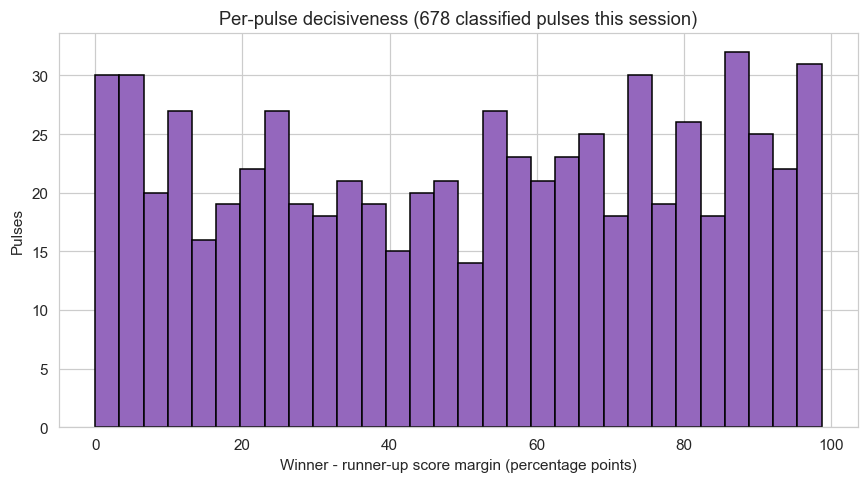

In [10]:
# Per-pulse decisiveness from the raw classifier log (finer-grained than the per-file
# aggregate above): margin = winner's score minus the runner-up's, on each individual
# pulse. A wide log exists because OpenBat logs every pulse, not just the file-level
# aggregate written to GUANO.
if PULSE_LOG_CSV.exists():
    species_cols = None
    pulse_rows = []
    with open(PULSE_LOG_CSV, newline='') as f:
        reader = csv_module.DictReader(f)
        species_cols = [c for c in reader.fieldnames if c not in
                         ('timestamp', 'type', 'species', 'confidence_pct', 'pulse_count')]
        for r in reader:
            if r['type'] != 'pulse':
                continue
            ts = datetime.strptime(r['timestamp'], '%Y-%m-%dT%H:%M:%SZ').replace(tzinfo=timezone.utc)
            if not (ob['timestamp_utc'].min() - timedelta(seconds=5) <= ts <= ob['end_utc'].max() + timedelta(seconds=5)):
                continue
            scores = sorted((float(r[c]) for c in species_cols), reverse=True)
            pulse_rows.append({'timestamp': ts, 'species': r['species'],
                                'confidence_pct': float(r['confidence_pct']),
                                'margin_pct': (scores[0] - scores[1]) * 100})
    pulse_log = pd.DataFrame(pulse_rows)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(pulse_log['margin_pct'], bins=30, color='tab:purple', edgecolor='black')
    ax.set_xlabel('Winner - runner-up score margin (percentage points)')
    ax.set_ylabel('Pulses')
    ax.set_title(f'Per-pulse decisiveness ({len(pulse_log)} classified pulses this session)')
    plt.tight_layout()
    plt.show()
else:
    print(f"Pulse-level log not found at {PULSE_LOG_CSV} — skipping per-pulse decisiveness plot.")


**How to read this:** this is finer-grained than the per-file confidence above — it looks at every individual echolocation pulse, not just the file-level summary. A margin near 0 means the classifier's top two guesses were nearly tied (a genuinely hard call, often between similar-sounding species like two *Myotis*); a large margin means one species clearly stood out. A pile-up near zero across many pulses would suggest the model is regularly choosing between look-alike species without much separation — useful context for why the confusion matrix above shows the mix-ups it does.


---
# Part B — Hardware / software quality

This half ignores species entirely — it's about whether the two systems hear the same events, and how strong/clean the capture is when they do.


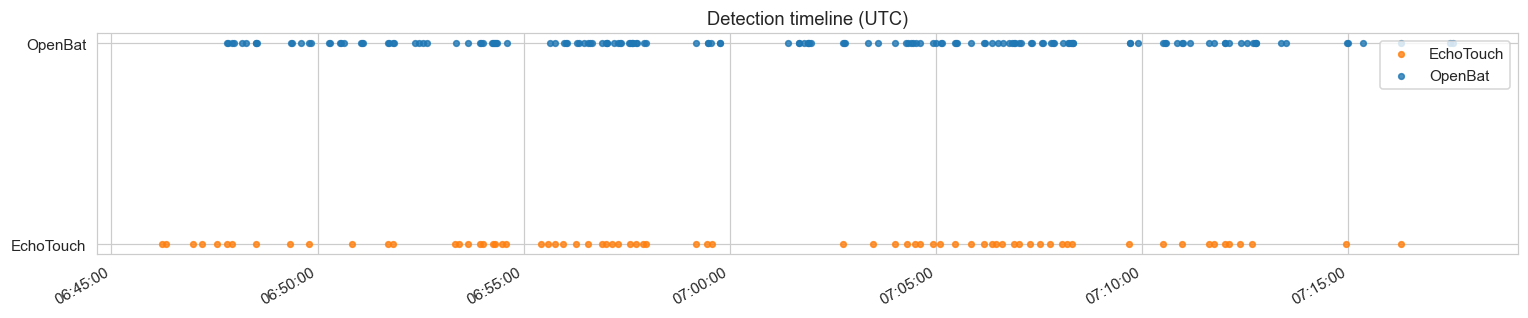

In [11]:
fig, ax = plt.subplots(figsize=(14, 3))
for src, g in df.groupby('source'):
    y = 1 if src == 'OpenBat' else 0
    ax.scatter(g['timestamp_utc'], [y] * len(g), s=14, color=COLORS[src], label=src, alpha=0.8)
ax.set_yticks([0, 1])
ax.set_yticklabels(['EchoTouch', 'OpenBat'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S', tz=timezone.utc))
fig.autofmt_xdate()
ax.set_title('Detection timeline (UTC)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


**How to read this:** each dot is one triggered pass. A gap in one row lined up with dots in the other row is the fastest way to spot a device missing activity the other one caught. Dense clusters that appear on both rows at once are corroborated activity bursts; a device with visibly more scattered/sparse dots overall is triggering less often, which could mean either a less sensitive trigger or a cleaner one (fewer false triggers) — section below on recall/counts helps disambiguate.


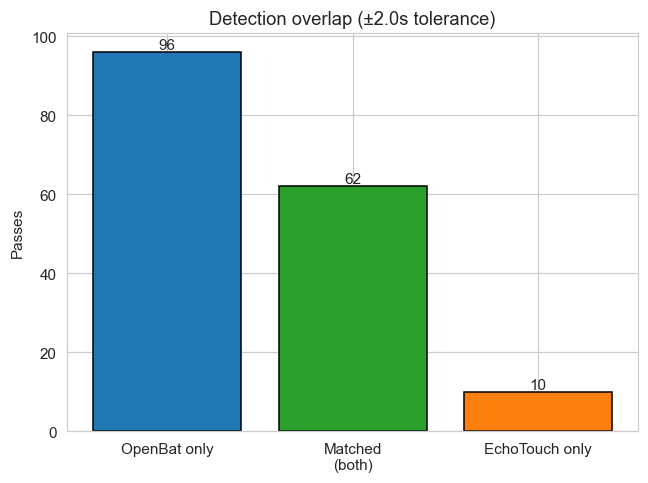

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = [len(ob_only), len(matches), len(et_only)]
bars = ax.bar(['OpenBat only', 'Matched\n(both)', 'EchoTouch only'], counts,
              color=['tab:blue', 'tab:green', 'tab:orange'], edgecolor='black')
ax.bar_label(bars)
ax.set_ylabel('Passes')
ax.set_title(f'Detection overlap (±{TOLERANCE_S}s tolerance)')
plt.tight_layout()
plt.show()


**How to read this:** "Matched" is activity both devices agree really happened — the most trustworthy bucket. A tall "OpenBat only" bar relative to "EchoTouch only" means OpenBat is triggering on things EchoTouch doesn't — that's either OpenBat catching real activity EchoTouch's trigger is too conservative to register, *or* OpenBat's trigger firing on non-bat noise (wind, insects, handling). Since OpenBat's pass length is much shorter than EchoTouch's (see below), spot-checking a handful of OpenBat-only files' spectrograms is the fastest way to tell which explanation is true — neither number alone proves it.


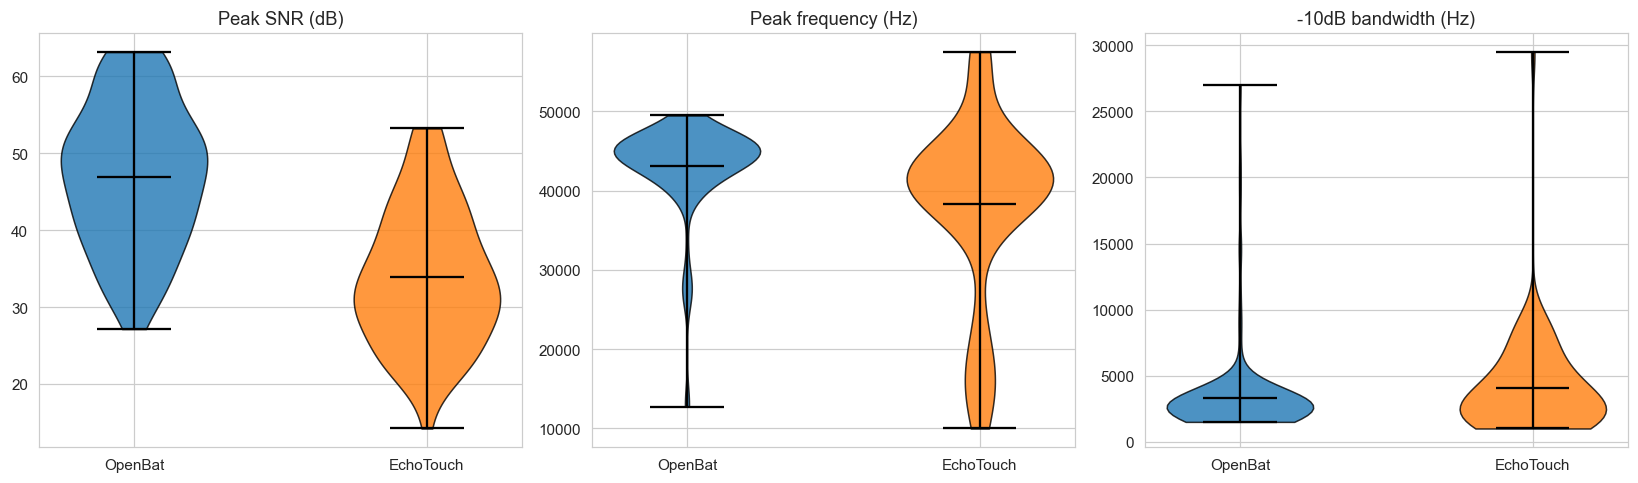

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in zip(axes, ['snr_db', 'peak_freq_hz', 'bandwidth_hz'],
                              ['Peak SNR (dB)', 'Peak frequency (Hz)', '-10dB bandwidth (Hz)']):
    violin(ax, [ob[metric].dropna(), et[metric].dropna()], ['OpenBat', 'EchoTouch'],
           [COLORS['OpenBat'], COLORS['EchoTouch']])
    ax.set_title(title)
plt.tight_layout()
plt.show()


**How to read this:** SNR is the clearest proxy for raw capture quality — higher means the bat call stands out more above the recording's noise floor, which generally means cleaner spectrograms and more reliable classification input. Peak frequency and bandwidth differences are more about what each device's trigger tends to catch (e.g. a device biased toward catching only the loudest/closest calls will skew differently) than about hardware fidelity — read those two more as "what kind of calls does each system typically capture" than "which is more sensitive." Keep in mind mic placement/distance to the bat during this session will shift SNR independent of hardware quality; a real conclusion needs the mics mounted together.


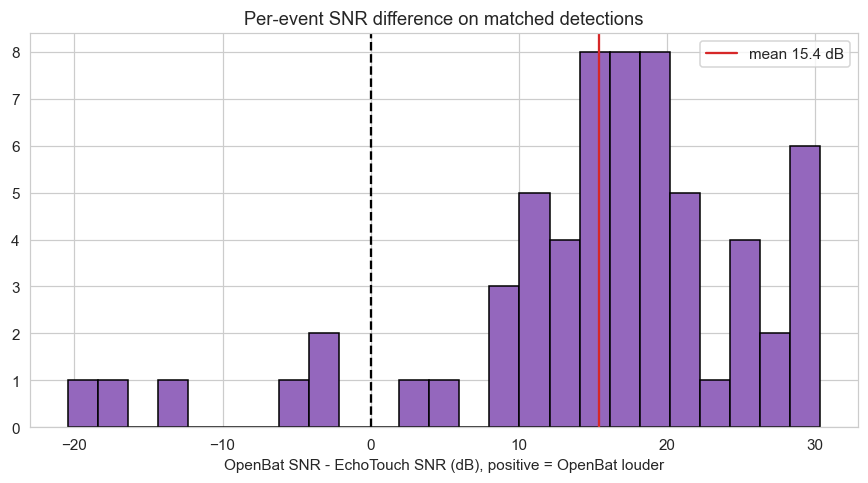

In [14]:
paired = match_df.merge(ob[['filename', 'snr_db']].rename(columns={'filename': 'ob_filename', 'snr_db': 'ob_snr_db'}), on='ob_filename') \
                  .merge(et[['filename', 'snr_db']].rename(columns={'filename': 'et_filename', 'snr_db': 'et_snr_db'}), on='et_filename')
paired['snr_diff_db'] = paired['ob_snr_db'] - paired['et_snr_db']

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(paired['snr_diff_db'].dropna(), bins=25, color='tab:purple', edgecolor='black')
ax.axvline(0, color='black', linestyle='--')
ax.axvline(paired['snr_diff_db'].mean(), color='tab:red', linestyle='-', label=f"mean {paired['snr_diff_db'].mean():.1f} dB")
ax.set_xlabel('OpenBat SNR - EchoTouch SNR (dB), positive = OpenBat louder')
ax.set_title('Per-event SNR difference on matched detections')
ax.legend()
plt.tight_layout()
plt.show()


**How to read this:** unlike the violin plot above, this compares SNR *pass by pass* on the same physical bat event — a cleaner apples-to-apples read since it cancels out session-wide differences in how many/which calls each device happened to catch. If the distribution sits mostly to the right of zero, OpenBat is capturing a stronger signal on the *same* events, which is a more hardware/software-attributable result than the split-population violin plot above. Every +6 dB is roughly a 4x jump in signal power relative to the noise floor, if you want a feel for the scale.


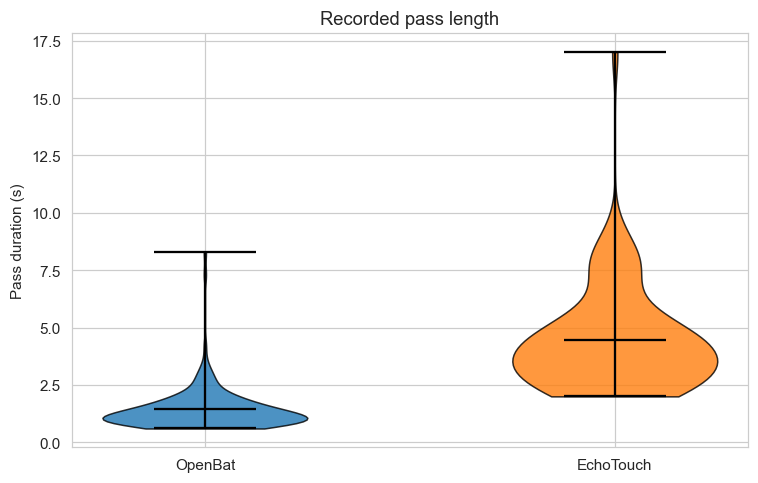

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
violin(ax, [ob['duration_s'].dropna(), et['duration_s'].dropna()], ['OpenBat', 'EchoTouch'],
       [COLORS['OpenBat'], COLORS['EchoTouch']])
ax.set_ylabel('Pass duration (s)')
ax.set_title('Recorded pass length')
plt.tight_layout()
plt.show()


**How to read this:** this is a software/configuration difference, not a hardware one — OpenBat currently writes a short fixed-length trigger window per pulse-run, while EchoTouch writes a longer variable-length window per full pass. Shorter files mean less context around each call (harder to classify borderline pulses, less room for pre/post-roll) but also less storage and more separated files per bat; longer files are the opposite trade-off. Worth knowing when interpreting the SNR/classification numbers above — OpenBat's classifier is working with less signal context per file than EchoTouch's.


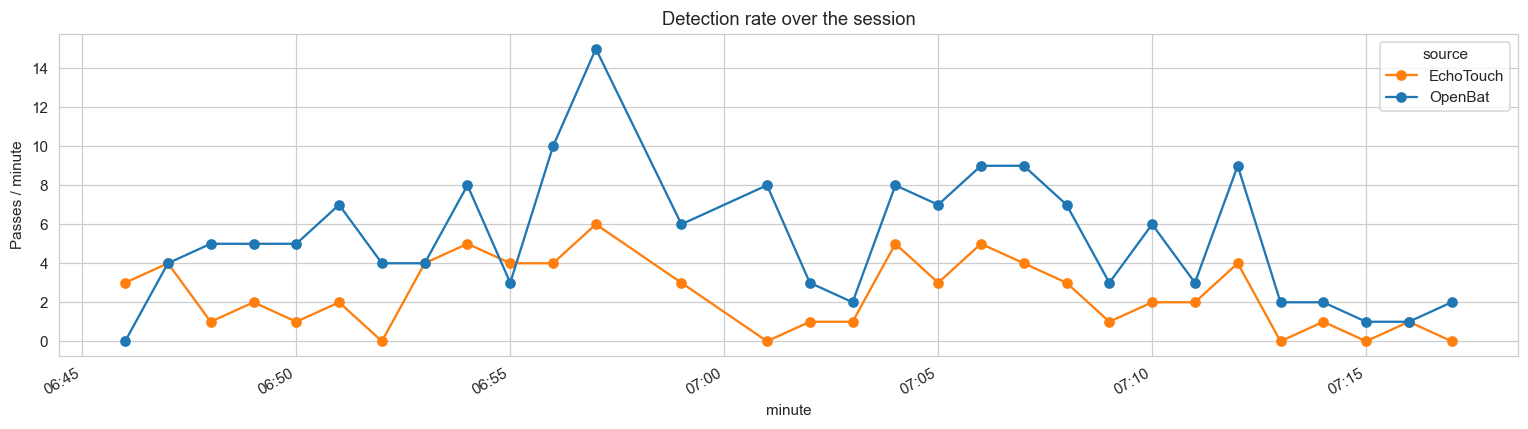

In [16]:
df['minute'] = df['timestamp_utc'].dt.floor('1min')
rate = df.groupby(['minute', 'source']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
rate.plot(ax=ax, marker='o', color=[COLORS.get(c, 'gray') for c in rate.columns])
ax.set_ylabel('Passes / minute')
ax.set_title('Detection rate over the session')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone.utc))
plt.tight_layout()
plt.show()


**How to read this:** lines that rise and fall together track real bat activity (both devices reacting to the same flurry of passes) — that's the expected, reassuring pattern. A device with a systematically higher line throughout (not just during bursts) is triggering more often across the board, which points to a genuine sensitivity/threshold difference rather than one-off noise; a line that spikes alone during an otherwise-quiet stretch is worth checking for a false-trigger source (wind gust, handling, insects) specific to that device.


## Summary

In [17]:
print("=== A. Species ID agreement ===\n")
print(f"Jointly-called events: {len(both_called)}")
if len(both_called):
    print(f"Agreement: {len(agree)}/{len(both_called)} ({agreement_rate:.1%})")
print(f"OpenBat mean confidence, all calls: {ob.loc[ob.species_auto_id != 'No ID', 'species_confidence'].mean()*100:.1f}%")
if len(groups[0]) and len(groups[1]):
    print(f"OpenBat mean confidence when it AGREED with EchoTouch:    {groups[0].mean():.1f}%")
    print(f"OpenBat mean confidence when it DISAGREED with EchoTouch: {groups[1].mean():.1f}%")

print("\n=== B. Hardware / software quality ===\n")
print(f"OpenBat passes: {len(ob)}  |  EchoTouch passes: {len(et)}")
print(f"Matched: {len(matches)}  |  OpenBat-only: {len(ob_only)}  |  EchoTouch-only: {len(et_only)}")
print(f"Mean SNR:      OpenBat {ob['snr_db'].mean():.1f} dB  |  EchoTouch {et['snr_db'].mean():.1f} dB")
print(f"Mean pass SNR difference on matched events (OpenBat - EchoTouch): {paired['snr_diff_db'].mean():.1f} dB")
print(f"Mean pass duration: OpenBat {ob['duration_s'].mean():.2f}s  |  EchoTouch {et['duration_s'].mean():.2f}s")


=== A. Species ID agreement ===

Jointly-called events: 33
Agreement: 22/33 (66.7%)
OpenBat mean confidence, all calls: 69.3%
OpenBat mean confidence when it AGREED with EchoTouch:    75.0%
OpenBat mean confidence when it DISAGREED with EchoTouch: 71.3%

=== B. Hardware / software quality ===

OpenBat passes: 158  |  EchoTouch passes: 72
Matched: 62  |  OpenBat-only: 96  |  EchoTouch-only: 10
Mean SNR:      OpenBat 47.0 dB  |  EchoTouch 33.9 dB
Mean pass SNR difference on matched events (OpenBat - EchoTouch): 15.4 dB
Mean pass duration: OpenBat 1.43s  |  EchoTouch 4.47s


## Notes & caveats

- **Species ID methodology:** OpenBat's calls in this dataset were backfilled from `bat_classifier_log.csv` (matching each pulse-level log entry to the recording it fell inside, by timestamp), not written live at capture time — this session predates that feature. Going forward, newly recorded sessions will have it written automatically by `AudioRecorder`; this notebook's loading code doesn't need to change either way.
- **Neither device is ground truth.** Every agreement/recall number here is *relative* — a disagreement could mean either classifier is wrong, and a pass unique to one device could be a genuine miss by the other, or a false trigger by the one that has it.
- **Sample rate differs** (384 kHz vs 256 kHz) — EchoTouch can't represent content above 128 kHz; OpenBat goes to 192 kHz. Any species calling above 128 kHz will structurally cap EchoTouch's SNR/bandwidth numbers for those passes, independent of sensitivity.
- **Pass length differs** (OpenBat ~0.9–1.4s fixed window vs. EchoTouch's variable ~2–17s) — this is a configuration choice, not a hardware limit, and it affects both the overlap-matching tolerance and how much context each classifier has to work with.
- **Mic placement/distance** between the two units during this session will shift SNR independent of hardware/software quality — mounting both mics on the same pole a few inches apart would make the SNR comparison much more attributable to the devices themselves.
